<a href="https://colab.research.google.com/github/SunitaJakhar/Predicting-Car-Prices-Using-Data-Analytics-and-Machine-Learning/blob/main/Predicting_Car_Prices_Using_Data_Analytics_and_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Predicting Price of cars using Data Analytics and Machine Learning models**

TASK 1: Exploratory Data Analysis (EDA)

In [ ]:
# IMPORT LIBRARIES : Pandas for data manipulation and Numpy for numerical operations.

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
# LOAD DATA : Load dataset into a pandas dataframe called df.

In [ ]:
df = pd.read_csv("/content/Predicting Car Prices Using Data Analytics and Machine Learning - Dataset.csv",header=None)

In [ ]:
df.head(10)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


In [ ]:
# ASSIGN COLUMN HEADERS

headers = ["risk_score", "loss_index", "brand", "fuel_category", "intake_type",
 "door_count", "chassis_style", "axle_config", "motor_placement",
 "axle_span", "body_length", "body_width", "body_height", "vehicle_weight", "engine_type",
 "cylinder_count", "engine-size", "injection_system", "bore_diameter", "piston_stroke",
 "compression_level", "horsepower", "rpm_peak", "urban_efficiency",
 "freeway_efficiency", "Price"]

In [ ]:
df.columns = headers

In [ ]:
# DATASET SHAPE & FIRST 10 ROWS

print(df.shape)

(205, 26)


In [ ]:
df.head(10)

,risk_score,loss_index,brand,fuel_category,intake_type,door_count,chassis_style,axle_config,motor_placement,axle_span,...,engine-size,injection_system,bore_diameter,piston_stroke,compression_level,horsepower,rpm_peak,urban_efficiency,freeway_efficiency,Price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,NaN,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,NaN,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,NaN,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,NaN


In [ ]:
# Descriptive statistics : (Mean, Median, Standard Deviation)

# Summary statistics for numerical columns
df.describe()

,risk_score,axle_span,body_length,body_width,body_height,vehicle_weight,engine-size,compression_level,urban_efficiency,freeway_efficiency
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


In [ ]:
# Mean
df.mean(numeric_only=True)

,0
risk_score,0.834146
axle_span,98.756585
body_length,174.049268
body_width,65.907805
body_height,53.724878
vehicle_weight,2555.565854
engine-size,126.907317
compression_level,10.142537
urban_efficiency,25.219512
freeway_efficiency,30.751220


In [ ]:
# Median
df.median(numeric_only=True)

,0
risk_score,1.0
axle_span,97.0
body_length,173.2
body_width,65.5
body_height,54.1
vehicle_weight,2414.0
engine-size,120.0
compression_level,9.0
urban_efficiency,24.0
freeway_efficiency,30.0


In [ ]:
# Standard Deviation
df.std(numeric_only=True)

,0
risk_score,1.245307
axle_span,6.021776
body_length,12.337289
body_width,2.145204
body_height,2.443522
vehicle_weight,520.680204
engine-size,41.642693
compression_level,3.972040
urban_efficiency,6.542142
freeway_efficiency,6.886443


In [ ]:
# Identify Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   risk_score          205 non-null    int64  
 1   loss_index          164 non-null    object 
 2   brand               205 non-null    object 
 3   fuel_category       205 non-null    object 
 4   intake_type         205 non-null    object 
 5   door_count          203 non-null    object 
 6   chassis_style       205 non-null    object 
 7   axle_config         205 non-null    object 
 8   motor_placement     205 non-null    object 
 9   axle_span           205 non-null    float64
 10  body_length         205 non-null    float64
 11  body_width          205 non-null    float64
 12  body_height         205 non-null    float64
 13  vehicle_weight      205 non-null    int64  
 14  engine_type         205 non-null    object 
 15  cylinder_count      205 non-null    object 
 16  engine-s

In [ ]:
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns

In [ ]:
# Display unique values
for col_name in cat_cols:
    unique_values = df[col_name].unique()
    print(f"Unique values in column '{col_name}':")
    print(unique_values)
    print()

Unique values in column 'loss_index':
[nan '164' '158' '192' '188' '121' '98' '81' '118' '148' '110' '145' '137'
 '101' '78' '106' '85' '107' '104' '113' '150' '129' '115' '93' '142'
 '161' '153' '125' '128' '122' '103' '168' '108' '194' '231' '119' '154'
 '74' '186' '83' '102' '89' '87' '77' '91' '134' '65' '197' '90' '94'
 '256' '95']

Unique values in column 'brand':
['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']

Unique values in column 'fuel_category':
['gas' 'diesel']

Unique values in column 'intake_type':
['std' 'turbo']

Unique values in column 'door_count':
['two' 'four' nan]

Unique values in column 'chassis_style':
['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']

Unique values in column 'axle_config':
['rwd' 'fwd' '4wd']

Unique values in column 'motor_placement':
['front' 'rear']

Unique values in 

TASK 2: Data Preprocessing & Feature Engineering

In [ ]:
# Data Cleaning: Handling Missing Values and Data Type Conversion

In [ ]:
# Replace null/missing values with NaN
df = df.replace("?", np.nan)
df.head(10)

,risk_score,loss_index,brand,fuel_category,intake_type,door_count,chassis_style,axle_config,motor_placement,axle_span,...,engine-size,injection_system,bore_diameter,piston_stroke,compression_level,horsepower,rpm_peak,urban_efficiency,freeway_efficiency,Price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,NaN,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,NaN,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,NaN,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,NaN


In [ ]:
# Applying Mean replacement for the numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:df[col] = df[col].fillna(df[col].mean())

In [ ]:
# Applying Mode replacement for the categorical columns
categorial_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.head(10)

,risk_score,loss_index,brand,fuel_category,intake_type,door_count,chassis_style,axle_config,motor_placement,axle_span,...,engine-size,injection_system,bore_diameter,piston_stroke,compression_level,horsepower,rpm_peak,urban_efficiency,freeway_efficiency,Price
0,3,161,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,161,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,161,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,161,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,161,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,161,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,13499


In [ ]:
# Confirmation of No Null Values

print(df.isnull().sum())

risk_score            0
loss_index            0
brand                 0
fuel_category         0
intake_type           0
door_count            0
chassis_style         0
axle_config           0
motor_placement       0
axle_span             0
body_length           0
body_width            0
body_height           0
vehicle_weight        0
engine_type           0
cylinder_count        0
engine-size           0
injection_system      0
bore_diameter         0
piston_stroke         0
compression_level     0
horsepower            0
rpm_peak              0
urban_efficiency      0
freeway_efficiency    0
Price                 0
dtype: int64


In [ ]:
# Convert Price & Horsepower data type from integer to float
df['Price'] = df['Price'].astype(float)
df['horsepower'] = df['horsepower'].astype(float)
print(df[['Price','horsepower']].dtypes)

Price         float64
horsepower    float64
dtype: object


In [ ]:
# VISUALIZATIONS - Import Matplotlib and Seaborn libraries for data visualization.
import matplotlib.pyplot as plt
import seaborn as sns

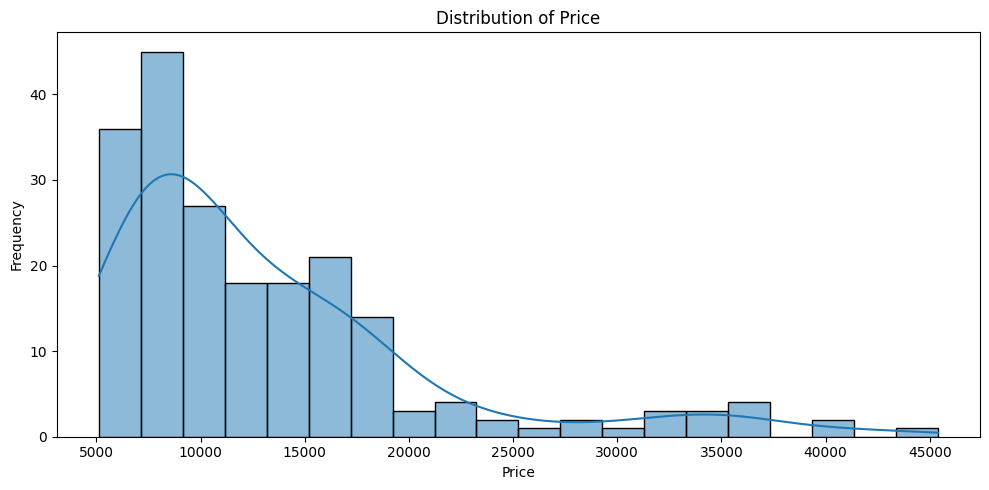

In [ ]:
# Histogram - Distribution of Price
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], bins=20, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

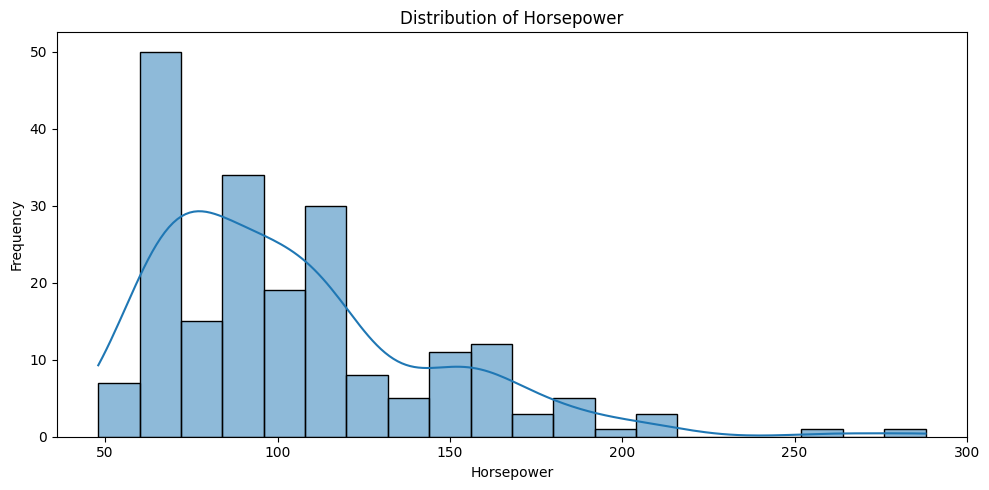

In [ ]:
# Histogram - Distribution of Horsepower
plt.figure(figsize=(10, 5))
sns.histplot(df['horsepower'], bins=20, kde=True)
plt.title('Distribution of Horsepower')
plt.xlabel('Horsepower')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

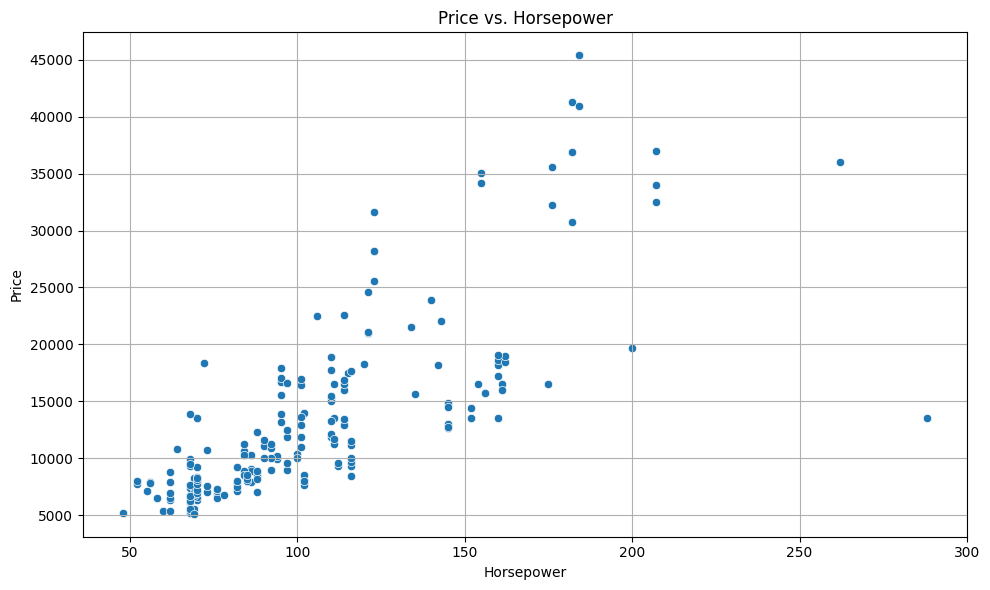

In [ ]:
# Scatter plot showing the relationship between 'Price' and 'horsepower'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='horsepower', y='Price', data=df)
plt.title('Price vs. Horsepower')
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.grid(True)
plt.tight_layout()
plt.show()

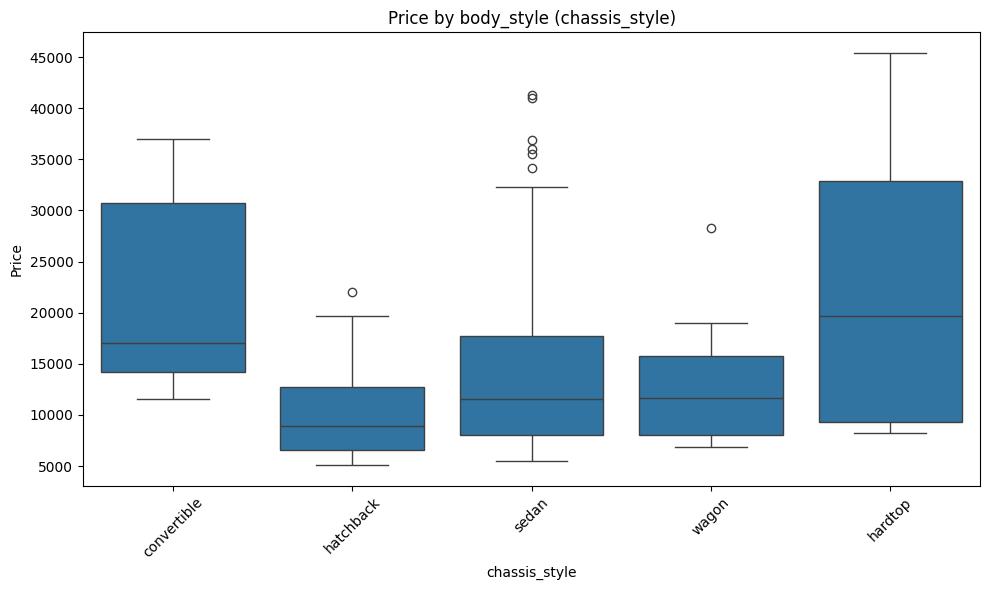

In [ ]:
# Boxplot - Price vs Body_style (chassis_style)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='chassis_style', y='Price')
plt.title('Price by body_style (chassis_style)')
plt.xlabel('chassis_style')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

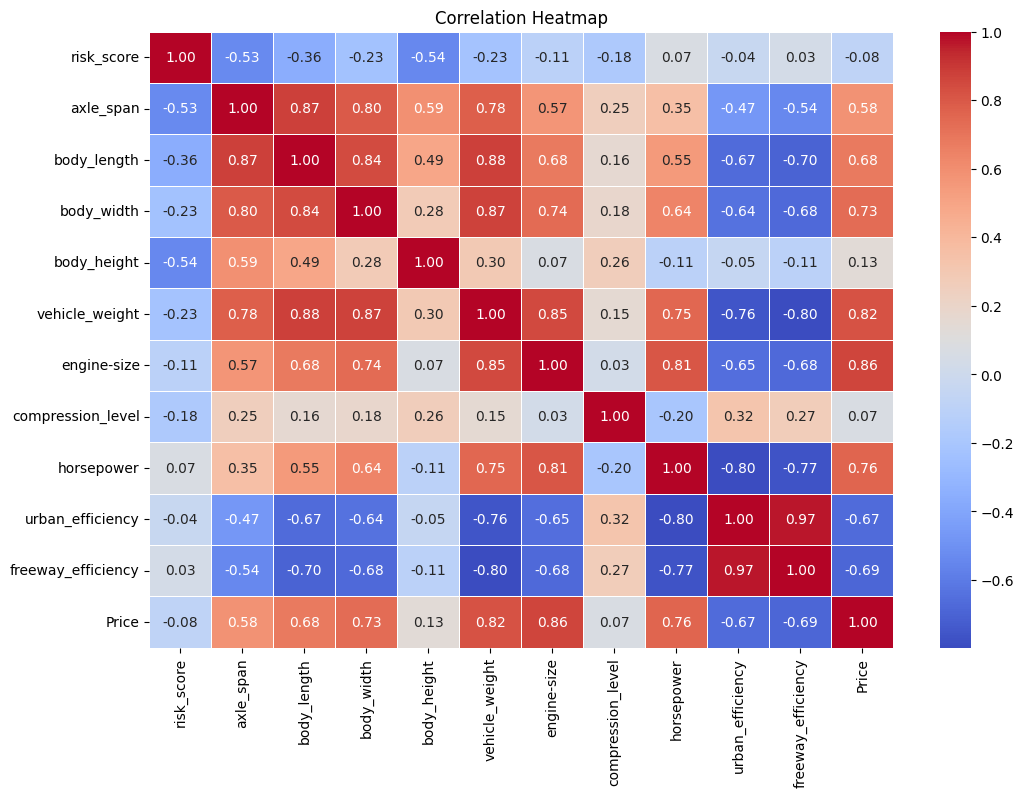

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# FEATURE ENGINEERING

In [ ]:
# Creating new column (city-L/100km)
df["city-L/100km"] = 235 / df["urban_efficiency"]
df.head(10)

,risk_score,loss_index,brand,fuel_category,intake_type,door_count,chassis_style,axle_config,motor_placement,axle_span,...,injection_system,bore_diameter,piston_stroke,compression_level,horsepower,rpm_peak,urban_efficiency,freeway_efficiency,Price,city-L/100km
0,3,161,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111.0,5000,21,27,13495.0,11.190476
1,3,161,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111.0,5000,21,27,16500.0,11.190476
2,1,161,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154.0,5000,19,26,16500.0,12.368421
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102.0,5500,24,30,13950.0,9.791667
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115.0,5500,18,22,17450.0,13.055556
5,2,161,audi,gas,std,two,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,8.5,110.0,5500,19,25,15250.0,12.368421
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,mpfi,3.19,3.40,8.5,110.0,5500,19,25,17710.0,12.368421
7,1,161,audi,gas,std,four,wagon,fwd,front,105.8,...,mpfi,3.19,3.40,8.5,110.0,5500,19,25,18920.0,12.368421
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,mpfi,3.13,3.40,8.3,140.0,5500,17,20,23875.0,13.823529
9,0,161,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,mpfi,3.13,3.40,7.0,160.0,5500,16,22,13499.0,14.687500


In [ ]:
# Apply binning - Horsepower into Low, Medium, High
df['hp_bin'] = pd.cut(df['horsepower'],bins=3,labels=['Low', 'Medium', 'High'])
print(df[['horsepower', 'hp_bin']].head())

   horsepower  hp_bin
0       111.0     Low
1       111.0     Low
2       154.0  Medium
3       102.0     Low
4       115.0     Low


In [ ]:
# Normalize engine-size - Using min & max normalization
df['engine_size_normalized'] = (df['engine-size'] - df['engine-size'].min()) / (df['engine-size'].max() - df['engine-size'].min())
print(df[['engine-size', 'engine_size_normalized']].head())

   engine-size  engine_size_normalized
0          130                0.260377
1          130                0.260377
2          152                0.343396
3          109                0.181132
4          136                0.283019


TASK 3: Model Development (Regression)

In [ ]:
# LINEAR REGRESSION - 80/20 Split

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
x = df[['horsepower', 'engine-size', 'body_width', 'body_length', 'axle_span', 'urban_efficiency', 'freeway_efficiency']]
y = df["Price"]

In [ ]:
# Train_Test_Split Dataset (80/20 Split)

x_train_80, x_test_80, y_train_80, y_test_80 = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# Train model - (80/20 Split)
lr_80 = LinearRegression()
lr_80.fit(x_train_80, y_train_80)

LinearRegression()

In [ ]:
# Predict - (80/20 Split)
lr_pred_80 = lr_80.predict(x_test_80)

In [ ]:
# RANDOM FOREST REGRESSOR - (80/20 Split)
from sklearn.ensemble import RandomForestRegressor

In [ ]:
#Train model - (80/20 Split)
rf_80 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_80.fit(x_train_80, y_train_80)

RandomForestRegressor(random_state=42)

In [ ]:
# Predict - (80/20 Split)
rf_pred_80 = rf_80.predict(x_test_80)

In [ ]:
# Import evaluation metrics - R² Score , MAE & MSE
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
# MODEL EVALUATION - Linear Regression & Random Forest - R2/MAE/MSE - (80/20 split)

def metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    return {'R2': r2, 'MAE': mae, 'MSE': mse}
lr_scores_80 = metrics(y_test_80, lr_pred_80)
rf_scores_80 = metrics(y_test_80, rf_pred_80)
print("Linear Regression 80/20 split:", lr_scores_80)
print("Random Forest 80/20 split:", rf_scores_80)

Linear Regression 80/20 split: {'R2': 0.7720680703736269, 'MAE': 3043.805007536372, 'MSE': 17771448.59575858}
Random Forest 80/20 split: {'R2': 0.9395379660245602, 'MAE': 1551.5238109404143, 'MSE': 4714117.633939478}


In [ ]:
# LINEAR REGRESSION - (70/30 split)

In [ ]:
# Train_Test_Split Dataset (70/30 split)
x_train_70, x_test_70, y_train_70, y_test_70 = train_test_split(x, y, test_size=0.3, random_state=42)

In [ ]:
# Train Model - (70/30 split)
lr_70 = LinearRegression()
lr_70.fit(x_train_70, y_train_70)

LinearRegression()

In [ ]:
# Predict - (70/30 Split)
lr_pred_70 = lr_70.predict(x_test_70)

In [ ]:
# RANDOM FOREST REGRESSOR - (70/30 split)

rf_70 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_70.fit(x_train_70, y_train_70)

RandomForestRegressor(random_state=42)

In [ ]:
# Predict - (70/30 Split)
rf_pred_70 = rf_70.predict(x_test_70)

In [ ]:
# MODEL EVALUATION - Linear Regression & Random Forest - R2/MAE/MSE - (70/30 split)

lr_scores_70 = metrics(y_test_70, lr_pred_70)
rf_scores_70 = metrics(y_test_70, rf_pred_70)
print("Linear Regression 70/30 split:", lr_scores_70)
print("Random Forest 70/30 split:", rf_scores_70)

Linear Regression 70/30 split: {'R2': 0.7158271672235323, 'MAE': 3095.3452094561094, 'MSE': 19506422.251210783}
Random Forest 70/30 split: {'R2': 0.9145721961307861, 'MAE': 1656.659331797235, 'MSE': 5864004.65514344}


Based on these metrics, the Random Forest Regressor performs significantly better than the Linear Regression model in predicting car prices for this 80/20 split, as evidenced by its much higher R² score and lower MAE and MSE.

Linear Regression 80/20 split: {'R2': 0.7720680703736269, 'MAE': 3043.805007536372, 'MSE': 17771448.59575858}

Random Forest 80/20 split: {'R2': 0.9395379660245602, 'MAE': 1551.5238109404143, 'MSE': 4714117.633939478}

Linear Regression 70/30 split: {'R2': 0.7158271672235323, 'MAE': 3095.3452094561094, 'MSE': 19506422.251210783}

Random Forest 70/30 split: {'R2': 0.9145721961307861, 'MAE': 1656.659331797235, 'MSE': 5864004.65514344}

**TASK 4: Classification Model**

In [ ]:
# Convert price into categories: Low Price, Medium Price & High Price
df['price-category'] = pd.qcut(df['Price'], 3, labels=['Low','Medium','High'])

In [ ]:
df.head(10)

,risk_score,loss_index,brand,fuel_category,intake_type,door_count,chassis_style,axle_config,motor_placement,axle_span,...,compression_level,horsepower,rpm_peak,urban_efficiency,freeway_efficiency,Price,city-L/100km,hp_bin,engine_size_normalized,price-category
0,3,161,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000,21,27,13495.0,11.190476,Low,0.260377,Medium
1,3,161,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000,21,27,16500.0,11.190476,Low,0.260377,High
2,1,161,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000,19,26,16500.0,12.368421,Medium,0.343396,High
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500,24,30,13950.0,9.791667,Low,0.181132,High
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500,18,22,17450.0,13.055556,Low,0.283019,High
5,2,161,audi,gas,std,two,sedan,fwd,front,99.8,...,8.5,110.0,5500,19,25,15250.0,12.368421,Low,0.283019,High
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,8.5,110.0,5500,19,25,17710.0,12.368421,Low,0.283019,High
7,1,161,audi,gas,std,four,wagon,fwd,front,105.8,...,8.5,110.0,5500,19,25,18920.0,12.368421,Low,0.283019,High
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,8.3,140.0,5500,17,20,23875.0,13.823529,Medium,0.264151,High
9,0,161,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,7.0,160.0,5500,16,22,13499.0,14.687500,Medium,0.264151,Medium


In [ ]:
# Import Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [ ]:
# Prepare features (x) and target (y) for classification
x = df[['horsepower', 'engine-size', 'body_width', 'body_length', 'axle_span', 'urban_efficiency', 'freeway_efficiency']]
y = df['price-category']

In [ ]:
# Split Dataset (80/20 split for classification)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# Make predictions on the scaled test set
y_pred = log_reg_model.predict(x_test_scaled)

In [ ]:
# Model Evaluation Using Accuracy Score & Confusion Matrix
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.7317
Confusion Matrix:
[[ 9  0  0]
 [ 0 13  2]
 [ 7  2  8]]


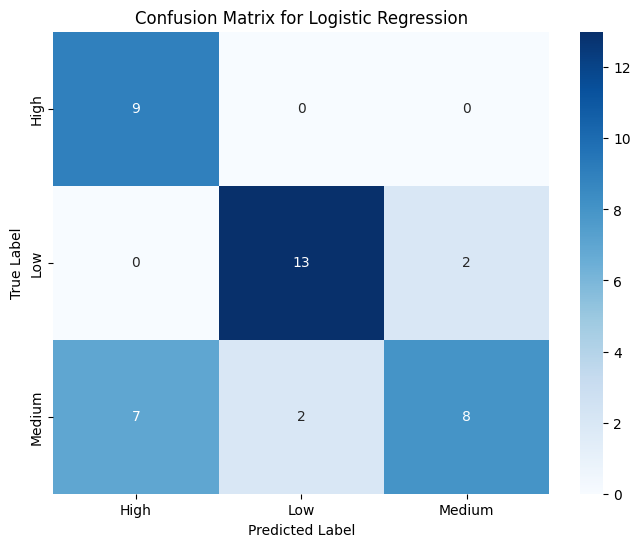

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=log_reg_model.classes_, yticklabels=log_reg_model.classes_)
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Task 5: Visualize Actual vs Predicted Prices (Random Forest Regressor 80/20 Split)

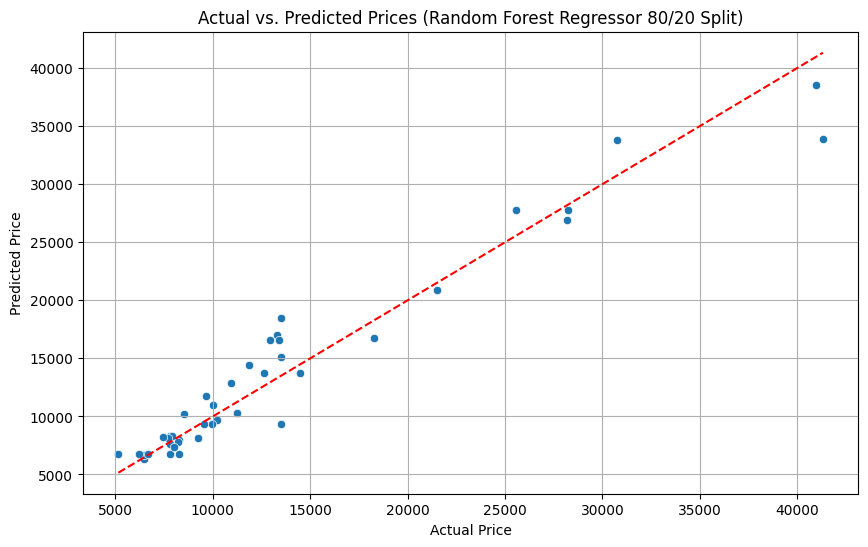

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_80, y=rf_pred_80)
plt.plot([y_test_80.min(), y_test_80.max()], [y_test_80.min(), y_test_80.max()], 'r--')
plt.title('Actual vs. Predicted Prices (Random Forest Regressor 80/20 Split)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.show()